In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from modules.onchain.patterns.ta_patterns import (
    compute_ta_indicators, 
    detect_candlestick_patterns, 
    _generate_signal
)

In [6]:
dates = pd.date_range(end=pd.Timestamp.now(), periods=100, freq='h')
prices = np.linspace(30000, 32000, 100) + np.random.randn(100) * 200

df = pd.DataFrame({
    "time": dates,
    "open": prices - np.random.rand(100)*50,
    "high": prices + np.random.rand(100)*50,
    "low": prices - np.random.rand(100)*50,
    "close": prices,
    "volume": np.random.randint(1000, 5000, 100)
})

In [7]:
df

,time,open,high,low,close,volume
0,2025-10-31 12:55:13.451486,30132.291959,30190.663837,30140.856968,30181.955677,2488
1,2025-10-31 13:55:13.451486,29866.929163,29906.106783,29878.772363,29889.840957,1596
2,2025-10-31 14:55:13.451486,30024.008797,30086.384328,30022.234312,30043.447070,3262
3,2025-10-31 15:55:13.451486,29915.049055,29956.659711,29945.215411,29948.768095,3030
4,2025-10-31 16:55:13.451486,29877.457417,29943.414932,29869.539212,29918.702218,2223
...,...,...,...,...,...,...
95,2025-11-04 11:55:13.451486,32039.834943,32106.331308,32059.167673,32087.239623,4335
96,2025-11-04 12:55:13.451486,31964.712365,31994.096786,31964.306981,31980.237327,2075
97,2025-11-04 13:55:13.451486,31814.530451,31823.343052,31813.124849,31819.251325,3122
98,2025-11-04 14:55:13.451486,32279.091915,32326.315525,32243.071785,32293.064618,4555


In [16]:
df = compute_ta_indicators(df)
df = detect_candlestick_patterns(df)
df.tail(5)

{"timestamp": "2025-11-04 16:40:45,970", "level": "INFO", "message": "Computed TA indicators successfully", "module": "ta_patterns", "function": "compute_ta_indicators", "line": 95}
{"timestamp": "2025-11-04 16:40:45,975", "level": "INFO", "message": "Detected candlestick patterns successfully", "module": "ta_patterns", "function": "detect_candlestick_patterns", "line": 114}


,time,open,high,low,close,volume,sma_7,sma_21,ema_8,ema_20,...,atr,bb_upper,bb_middle,bb_lower,obv,volume_pct_change,cdl_engulfing,cdl_harami,cdl_hammer,cdl_shootingstar
95,2025-11-04 11:55:13.451486,32039.834943,32106.331308,32059.167673,32087.239623,4335,31904.599460,31714.844102,31899.183708,31749.741571,...,301.755808,32246.157448,31713.962407,31181.767366,-14987.0,-1.767505,0,0,0,0
96,2025-11-04 12:55:13.451486,31964.712365,31994.096786,31964.306981,31980.237327,2075,31985.798349,31726.642165,31917.195624,31771.693548,...,288.982725,32266.645005,31743.032907,31219.420808,-17062.0,-52.133795,0,0,0,0
97,2025-11-04 13:55:13.451486,31814.530451,31823.343052,31813.124849,31819.251325,3122,31924.065253,31746.662355,31895.430224,31776.222860,...,280.277707,32258.780714,31738.926116,31219.071518,-20184.0,50.457831,0,0,0,0
98,2025-11-04 14:55:13.451486,32279.091915,32326.315525,32243.071785,32293.064618,4555,31992.082043,31765.313663,31983.793423,31825.445885,...,296.476742,32289.890834,31797.334143,31304.777452,-15629.0,45.900064,0,0,0,0
99,2025-11-04 15:55:13.451486,31972.212295,31985.070291,31951.150598,31979.298843,3217,31993.327207,31805.999129,31982.794627,31840.098547,...,299.722262,32307.698194,31810.453439,31313.208685,-18846.0,-29.374314,0,0,0,0


In [20]:
last_row = df.iloc[-1]
rsi = last_row["rsi"]
macd_hist = last_row["macd_hist"]

In [21]:
pattern = "none"
pattern_direction = None

if last_row["cdl_engulfing"] != 0:
    pattern = "bullish_engulfing" if last_row["cdl_engulfing"] > 0 else "bearish_engulfing"
    pattern_direction = "bullish" if last_row["cdl_engulfing"] > 0 else "bearish"
elif last_row["cdl_harami"] != 0:
    pattern = "bullish_harami" if last_row["cdl_harami"] > 0 else "bearish_harami"
    pattern_direction = "bullish" if last_row["cdl_harami"] > 0 else "bearish"
elif last_row["cdl_hammer"] != 0:
    pattern = "hammer"
    pattern_direction = "bullish"
elif last_row["cdl_shootingstar"] != 0:
    pattern = "shooting_star"
    pattern_direction = "bearish"

print(last_row)
print(pattern)
print(pattern_direction)

time                 2025-11-04 15:55:13.451486
open                               31972.212295
high                               31985.070291
low                                31951.150598
close                              31979.298843
volume                                     3217
sma_7                              31993.327207
sma_21                             31805.999129
ema_8                              31982.794627
ema_20                             31840.098547
rsi                                   52.973565
macd                                 157.845806
macd_signal                           150.22042
macd_hist                              7.625386
atr                                  299.722262
bb_upper                           32307.698194
bb_middle                          31810.453439
bb_lower                           31313.208685
obv                                    -18846.0
volume_pct_change                    -29.374314
cdl_engulfing                           

In [13]:
signal, explanation = _generate_signal(rsi, macd_hist, pattern, pattern_direction)
print("Signal:", signal)
print("Explanation:", explanation)

Signal: bullish
Explanation: MACD histogram > 0 suggests bullish bias


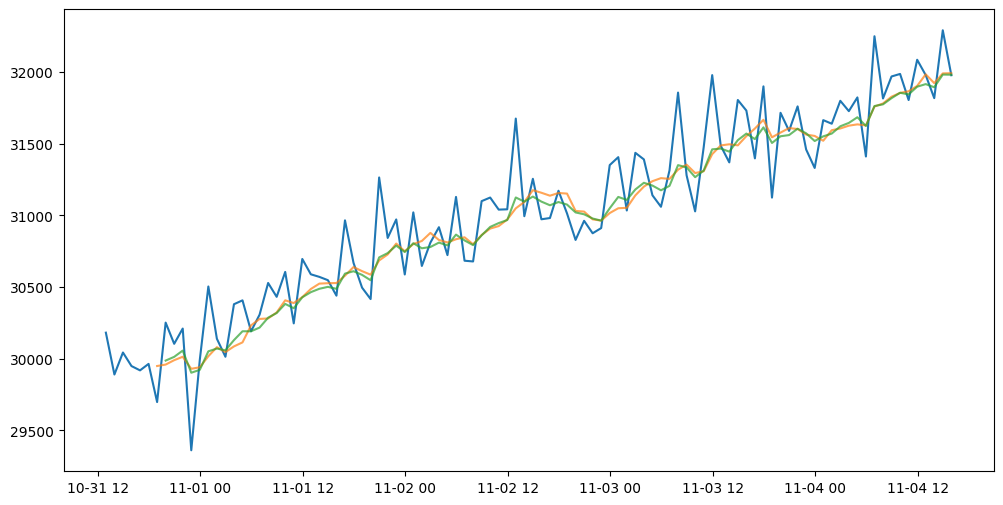

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df["time"], df["close"], label="Close", lw=1.5)
plt.plot(df["time"], df["sma_7"], label="SMA 7", alpha=0.7)
plt.plot(df["time"], df["ema_8"], label="EMA 8", alpha=0.7)

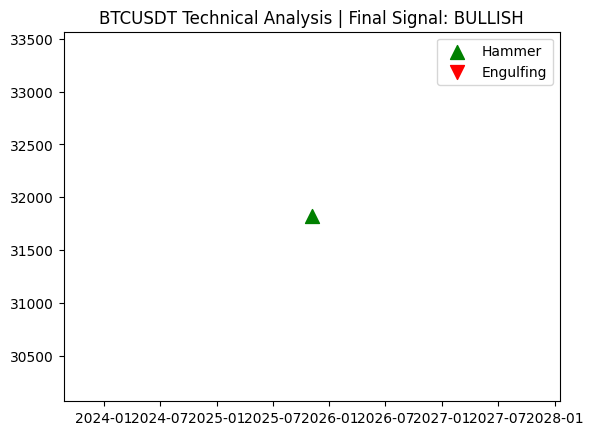

In [15]:
plt.scatter(df.loc[df["cdl_hammer"] != 0, "time"], df.loc[df["cdl_hammer"] != 0, "close"],
            color="green", label="Hammer", marker="^", s=100)
plt.scatter(df.loc[df["cdl_engulfing"] != 0, "time"], df.loc[df["cdl_engulfing"] != 0, "close"],
            color="red", label="Engulfing", marker="v", s=100)

plt.legend()
plt.title(f"BTCUSDT Technical Analysis | Final Signal: {signal.upper()}")
plt.show()